In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print(f"XGBoost version: {xgb.__version__}")
print("All imports successful.")

XGBoost version: 3.1.3
All imports successful.


In [2]:
farm_a_path     = "C:/Users/cjcha/Downloads/CARE_To_Compare/CARE_To_Compare/Wind Farm A"
datasets_path_a = f"{farm_a_path}/datasets"

event_info_a = pd.read_csv(f"{farm_a_path}/event_info.csv", sep=";")

dfs_a = []
for fname in os.listdir(datasets_path_a):
    if fname.endswith(".csv"):
        df_temp             = pd.read_csv(os.path.join(datasets_path_a, fname), sep=";").copy()
        df_temp["event_id"] = int(fname.replace(".csv", ""))
        dfs_a.append(df_temp)

df_raw_a = pd.concat(dfs_a, ignore_index=True)
df_raw_a["event_id"] = df_raw_a["event_id"].astype(int)
df_raw_a = df_raw_a.merge(
    event_info_a[["event_id", "event_label", "event_description"]],
    on="event_id", how="left"
)
df_raw_a["label"] = (df_raw_a["event_label"] == "anomaly").astype(int)

print(f"Farm A rows:    {len(df_raw_a):,}")
print(f"Farm A columns: {len(df_raw_a.columns)}")
print(f"\nLabel distribution:")
print(df_raw_a["label"].value_counts())
print(f"\nEvent breakdown:")
print(event_info_a[["event_id", "event_label", "event_description"]].to_string())

Farm A rows:    1,196,747
Farm A columns: 90

Label distribution:
label
1    649789
0    546958
Name: count, dtype: int64

Event breakdown:
    event_id event_label          event_description
0         68     anomaly        Transformer failure
1         22     anomaly            Hydraulic group
2         72     anomaly            Gearbox failure
3         73     anomaly            Hydraulic group
4          0     anomaly  Generator bearing failure
5         26     anomaly            Hydraulic group
6         40     anomaly  Generator bearing failure
7         42     anomaly            Hydraulic group
8         10     anomaly            Gearbox failure
9         45     anomaly            Hydraulic group
10        84     anomaly            Hydraulic group
11        25      normal                        NaN
12        69      normal                        NaN
13        13      normal                        NaN
14        24      normal                        NaN
15         3      normal    

In [3]:
train_a = df_raw_a[df_raw_a["train_test"] == "train"].copy()
pred_a  = df_raw_a[df_raw_a["train_test"] == "prediction"].copy()

print(f"Farm A training rows:   {len(train_a):,}")
print(f"Farm A prediction rows: {len(pred_a):,}")
print(f"\nTraining anomaly rate: {train_a['label'].mean()*100:.1f}%")

Farm A training rows:   1,146,154
Farm A prediction rows: 50,593

Training anomaly rate: 54.6%


In [4]:
farm_a_sensors = [
    # Core gearbox and bearing sensors
    "sensor_12_avg",          # gearbox oil temperature
    "sensor_11_avg",          # gearbox bearing temperature (high speed shaft)
    "sensor_13_avg",          # generator bearing temperature (Drive End)
    "sensor_18_avg",          # generator RPM
    "wind_speed_3_avg",       # wind speed

    # Hydraulic group (most common fault type in Farm A)
    "sensor_41_avg",          # hydraulic group oil temperature

    # Generator stator windings: generator bearing faults
    "sensor_15_avg",          # stator winding phase 1
    "sensor_16_avg",          # stator winding phase 2
    "sensor_17_avg",          # stator winding phase 3

    # HV transformer temperatures: transformer failure
    "sensor_38_avg",          # HV transformer phase L1
    "sensor_39_avg",          # HV transformer phase L2
    "sensor_40_avg",          # HV transformer phase L3

    # Nacelle and rotor
    "sensor_43_avg",          # nacelle temperature
    "sensor_52_avg",          # rotor RPM

    # Power output
    "power_29_avg",           # active power output
    "reactive_power_27_avg",  # reactive power
]

farm_a_sensors = [s for s in farm_a_sensors if s in train_a.columns]

print(f"Farm A sensors selected: {len(farm_a_sensors)}")
for s in farm_a_sensors:
    print(f"  {s}")

Farm A sensors selected: 16
  sensor_12_avg
  sensor_11_avg
  sensor_13_avg
  sensor_18_avg
  wind_speed_3_avg
  sensor_41_avg
  sensor_15_avg
  sensor_16_avg
  sensor_17_avg
  sensor_38_avg
  sensor_39_avg
  sensor_40_avg
  sensor_43_avg
  sensor_52_avg
  power_29_avg
  reactive_power_27_avg


In [5]:
def engineer_features(df, feature_cols):
    """Add rolling, delta and z-score features per turbine per event."""
    df     = df.sort_values(["asset_id", "event_id", "time_stamp"]).copy()
    groups = df.groupby(["asset_id", "event_id"])

    for col in feature_cols:
        df[f"{col}_roll_mean_6h"] = groups[col].transform(
            lambda x: x.rolling(36, min_periods=1).mean()
        )
        df[f"{col}_roll_std_6h"] = groups[col].transform(
            lambda x: x.rolling(36, min_periods=1).std()
        )
        df[f"{col}_roll_mean_24h"] = groups[col].transform(
            lambda x: x.rolling(144, min_periods=1).mean()
        )
        df[f"{col}_delta"] = groups[col].transform(
            lambda x: x.diff()
        )

    return df


def add_zscores(df_full, df_train, feature_cols):
    """
    Compute per-turbine per-event baseline from training data only
    then apply z-scores to the full DataFrame.
    """
    baseline = (
        df_train.groupby(["asset_id", "event_id"])[feature_cols]
        .agg(["mean", "std"])
    )
    baseline.columns = [f"{col}_{stat}" for col, stat in baseline.columns]
    baseline         = baseline.reset_index()

    df_full = df_full.merge(baseline, on=["asset_id", "event_id"], how="left")

    for col in feature_cols:
        df_full[f"{col}_zscore"] = (
            (df_full[col] - df_full[f"{col}_mean"]) /
            df_full[f"{col}_std"].replace(0, 1)
        )

    return df_full


def build_feature_list(base_sensors):
    """Build full list of engineered feature column names."""
    return (
        base_sensors +
        [f"{c}_roll_mean_6h"  for c in base_sensors] +
        [f"{c}_roll_std_6h"   for c in base_sensors] +
        [f"{c}_roll_mean_24h" for c in base_sensors] +
        [f"{c}_delta"         for c in base_sensors] +
        [f"{c}_zscore"        for c in base_sensors]
    )


print("Feature engineering functions defined.")

Feature engineering functions defined.


In [6]:
print("Engineering Farm A training features...")
train_a_eng = engineer_features(train_a, farm_a_sensors)
train_a_eng = add_zscores(train_a_eng, train_a_eng, farm_a_sensors)

print("Engineering Farm A prediction features...")
pred_a_eng  = engineer_features(pred_a, farm_a_sensors)
pred_a_eng  = add_zscores(pred_a_eng, train_a_eng, farm_a_sensors)

a_features  = build_feature_list(farm_a_sensors)
a_features  = [f for f in a_features if f in train_a_eng.columns]

X_train_a   = train_a_eng[a_features].fillna(0)
y_train_a   = train_a_eng["label"].values
X_pred_a    = pred_a_eng[a_features].fillna(0)
y_pred_a    = pred_a_eng["label"].values

print(f"\nFarm A features:        {len(a_features)}")
print(f"Farm A training rows:   {len(X_train_a):,}")
print(f"Farm A prediction rows: {len(X_pred_a):,}")
print(f"\nTraining anomaly rate:  {y_train_a.mean()*100:.1f}%")

Engineering Farm A training features...
Engineering Farm A prediction features...

Farm A features:        96
Farm A training rows:   1,146,154
Farm A prediction rows: 50,593

Training anomaly rate:  54.6%


In [7]:
a_normal  = (y_train_a == 0).sum()
a_anomaly = (y_train_a == 1).sum()
a_spw     = a_normal / a_anomaly

print(f"Normal rows:      {a_normal:,}")
print(f"Anomaly rows:     {a_anomaly:,}")
print(f"Imbalance ratio:  {a_spw:.2f}:1")
print(f"scale_pos_weight: {a_spw:.2f}")

Normal rows:      520,894
Anomaly rows:     625,260
Imbalance ratio:  0.83:1
scale_pos_weight: 0.83


In [8]:
print("Training Farm A XGBoost model...")

model_a = xgb.XGBClassifier(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = a_spw,
    eval_metric      = "aucpr",
    random_state     = 42,
    n_jobs           = -1
)

model_a.fit(
    X_train_a, y_train_a,
    eval_set=[(X_train_a, y_train_a)],
    verbose=50
)

print("\nTraining complete.")

Training Farm A XGBoost model...
[0]	validation_0-aucpr:0.76770
[50]	validation_0-aucpr:0.94322
[100]	validation_0-aucpr:0.97791
[150]	validation_0-aucpr:0.99133
[200]	validation_0-aucpr:0.99751
[250]	validation_0-aucpr:0.99919
[299]	validation_0-aucpr:0.99959

Training complete.


Farm A Accuracy: 98.8%

Detailed breakdown:
              precision    recall  f1-score   support

  Normal (0)       0.99      0.99      0.99     26064
 Anomaly (1)       0.98      0.99      0.99     24529

    accuracy                           0.99     50593
   macro avg       0.99      0.99      0.99     50593
weighted avg       0.99      0.99      0.99     50593



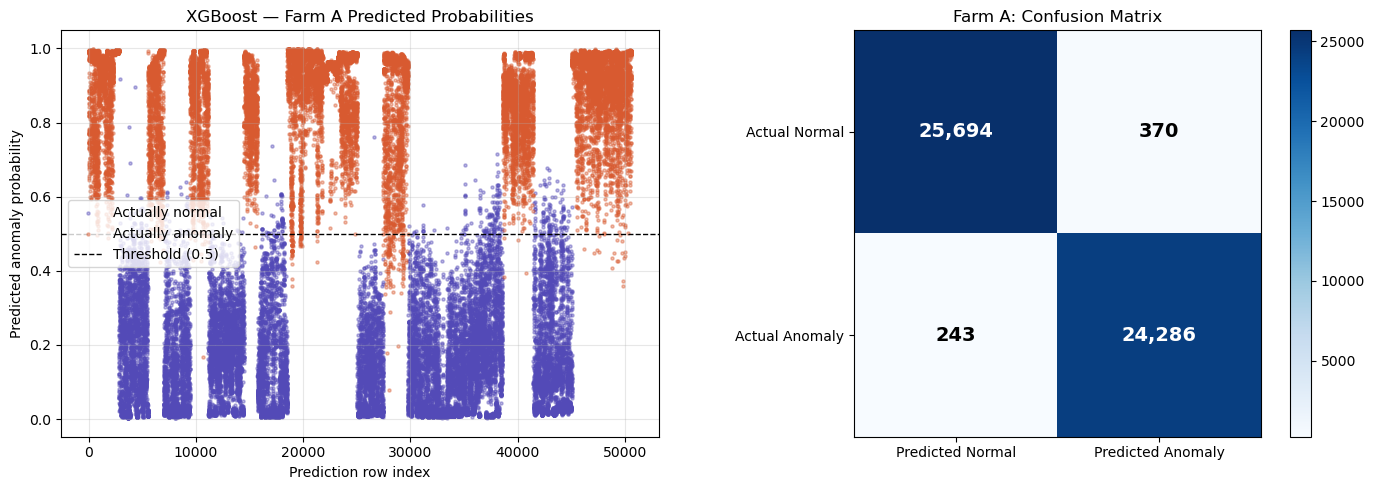


True Positives  (anomaly correctly flagged): 24,286
True Negatives  (normal correctly ignored):  25,694
False Positives (false alarms):              370
False Negatives (missed faults):             243


In [9]:
preds_a = model_a.predict(X_pred_a)
probs_a = model_a.predict_proba(X_pred_a)[:, 1]
acc_a   = accuracy_score(y_pred_a, preds_a)

print(f"Farm A Accuracy: {acc_a*100:.1f}%")
print("\nDetailed breakdown:")
print(classification_report(
    y_pred_a, preds_a,
    target_names=["Normal (0)", "Anomaly (1)"]
))

cm_a = confusion_matrix(y_pred_a, preds_a)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

normal_mask_a  = y_pred_a == 0
anomaly_mask_a = y_pred_a == 1

axes[0].scatter(
    np.where(normal_mask_a)[0],  probs_a[normal_mask_a],
    color="#534AB7", alpha=0.4, s=5, label="Actually normal"
)
axes[0].scatter(
    np.where(anomaly_mask_a)[0], probs_a[anomaly_mask_a],
    color="#D85A30", alpha=0.4, s=5, label="Actually anomaly"
)
axes[0].axhline(y=0.5, color="black", linestyle="--",
                linewidth=1, label="Threshold (0.5)")
axes[0].set_xlabel("Prediction row index")
axes[0].set_ylabel("Predicted anomaly probability")
axes[0].set_title("XGBoost — Farm A Predicted Probabilities")
axes[0].legend()
axes[0].grid(alpha=0.3)

im = axes[1].imshow(cm_a, cmap="Blues")
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(["Predicted Normal", "Predicted Anomaly"])
axes[1].set_yticklabels(["Actual Normal", "Actual Anomaly"])
axes[1].set_title("Farm A: Confusion Matrix")
for i in range(2):
    for j in range(2):
        axes[1].text(
            j, i, f"{cm_a[i,j]:,}", ha="center", va="center",
            color="white" if cm_a[i,j] > cm_a.max()/2 else "black",
            fontsize=14, fontweight="bold"
        )
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.savefig("xgb_a_results.png", dpi=150, bbox_inches="tight")
plt.show()

tn_a, fp_a, fn_a, tp_a = cm_a.ravel()
print(f"\nTrue Positives  (anomaly correctly flagged): {tp_a:,}")
print(f"True Negatives  (normal correctly ignored):  {tn_a:,}")
print(f"False Positives (false alarms):              {fp_a:,}")
print(f"False Negatives (missed faults):             {fn_a:,}")

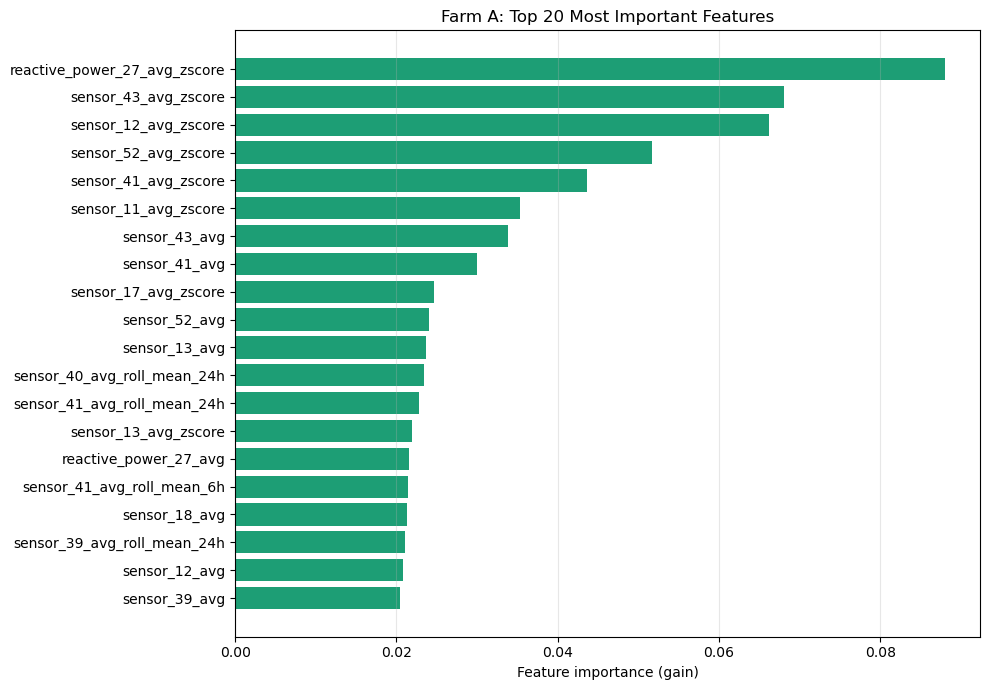

Top 10 Farm A features:
                     feature  importance
reactive_power_27_avg_zscore    0.087971
        sensor_43_avg_zscore    0.068109
        sensor_12_avg_zscore    0.066195
        sensor_52_avg_zscore    0.051716
        sensor_41_avg_zscore    0.043633
        sensor_11_avg_zscore    0.035356
               sensor_43_avg    0.033823
               sensor_41_avg    0.029973
        sensor_17_avg_zscore    0.024708
               sensor_52_avg    0.024060


In [10]:
a_importance = pd.DataFrame({
    "feature":    a_features,
    "importance": model_a.feature_importances_
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top20_a = a_importance.head(20)
ax.barh(
    top20_a["feature"][::-1],
    top20_a["importance"][::-1],
    color="#1D9E75", edgecolor="none"
)
ax.set_xlabel("Feature importance (gain)")
ax.set_title("Farm A: Top 20 Most Important Features")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("xgb_a_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 Farm A features:")
print(a_importance[["feature", "importance"]].head(10).to_string(index=False))

Total pred rows:       50,593
Normal operation rows: 29,355
Rows filtered out:     21,238


C:\Users\cjcha\AppData\Local\Temp\ipykernel_27836\3358356088.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pred_a_eng["hours_to_event"] = (



Anomaly event: % rows above threshold: 92.7%
Normal event: % rows above threshold: 0.1%
Separation:                             92.6 pp
First detection:                        48.0h before fault


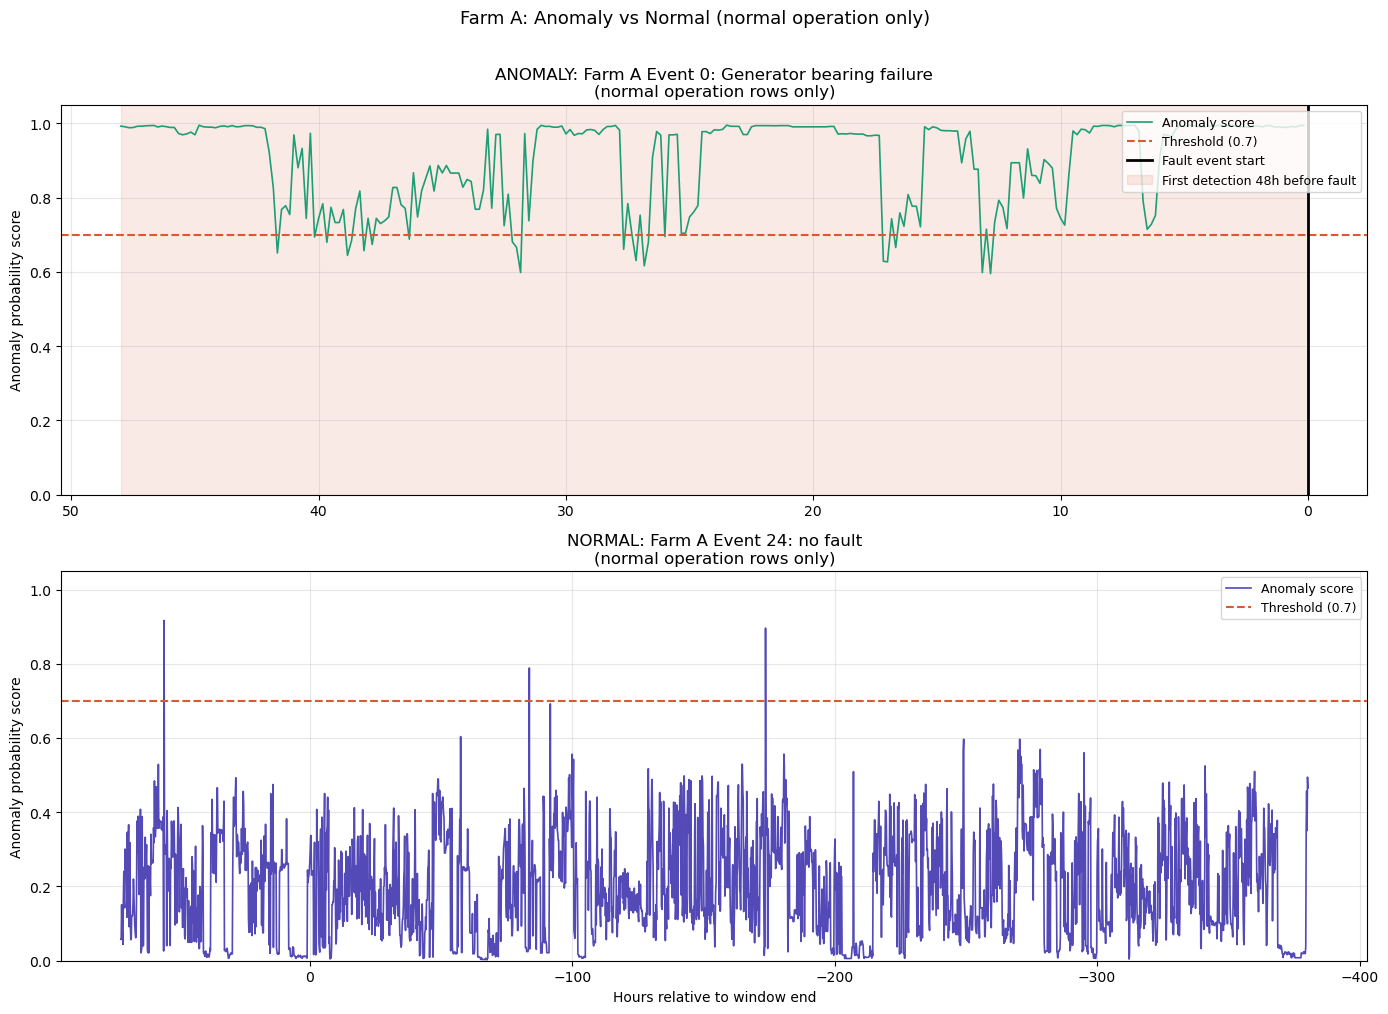

Plot saved as xgb_a_anomaly_vs_normal.png


In [11]:
threshold_a = 0.7

pred_a_eng["score"]      = probs_a
pred_a_eng["predicted"]  = (probs_a >= threshold_a).astype(int)
pred_a_eng["time_stamp"] = pd.to_datetime(pred_a_eng["time_stamp"])

event_times_a                = event_info_a[["event_id", "event_start"]].copy()
event_times_a["event_start"] = pd.to_datetime(event_times_a["event_start"])

if "hours_to_event" not in pred_a_eng.columns:
    pred_a_eng = pred_a_eng.merge(event_times_a, on="event_id", how="left")
    pred_a_eng["hours_to_event"] = (
        (pred_a_eng["event_start"] - pred_a_eng["time_stamp"])
        .dt.total_seconds() / 3600
    )

# Filter to normal operation only
pred_a_active = pred_a_eng[pred_a_eng["status_type_id"] == 0].copy()

print(f"Total pred rows:       {len(pred_a_eng):,}")
print(f"Normal operation rows: {len(pred_a_active):,}")
print(f"Rows filtered out:     {len(pred_a_eng) - len(pred_a_active):,}")

# Find anomaly event with earliest clean detection
best_a_id    = None
best_a_hours = -999

for eid in pred_a_active[
    pred_a_active["event_label"] == "anomaly"
]["event_id"].unique():
    detected = pred_a_active[
        (pred_a_active["event_id"] == eid) &
        (pred_a_active["score"] >= threshold_a) &
        (pred_a_active["hours_to_event"] > 0)
    ]
    if len(detected) > 0:
        earliest = detected["hours_to_event"].max()
        if earliest > best_a_hours:
            best_a_hours = earliest
            best_a_id    = eid

# Pick a normal event to compare against
normal_a_ids = pred_a_active[
    pred_a_active["event_label"] == "normal"
]["event_id"].unique()
normal_a_id  = normal_a_ids[0] if len(normal_a_ids) > 0 else None

if best_a_id is not None:
    anomaly_plot = pred_a_active[
        pred_a_active["event_id"] == best_a_id
    ].sort_values("hours_to_event", ascending=False)

    fault_desc = event_info_a[
        event_info_a["event_id"] == best_a_id
    ]["event_description"].values[0]

    fig, axes = plt.subplots(
        2 if normal_a_id is not None else 1,
        1, figsize=(14, 10 if normal_a_id is not None else 5)
    )
    if normal_a_id is None:
        axes = [axes]

    # Top — anomaly event
    ax = axes[0]
    ax.plot(
        anomaly_plot["hours_to_event"],
        anomaly_plot["score"],
        color="#1D9E75", linewidth=1.2, label="Anomaly score"
    )
    ax.axhline(y=threshold_a, color="#D85A30", linestyle="--",
               linewidth=1.5, label=f"Threshold ({threshold_a})")
    ax.axvline(x=0, color="black", linestyle="-",
               linewidth=2, label="Fault event start")

    detected = anomaly_plot[
        (anomaly_plot["score"] >= threshold_a) &
        (anomaly_plot["hours_to_event"] > 0)
    ]
    if len(detected) > 0:
        ax.axvspan(
            0, detected["hours_to_event"].max(),
            alpha=0.12, color="#D85A30",
            label=f"First detection {best_a_hours:.0f}h before fault"
        )

    ax.set_title(
        f"ANOMALY: Farm A Event {best_a_id}: {fault_desc}\n"
        f"(normal operation rows only)"
    )
    ax.set_ylabel("Anomaly probability score")
    ax.set_ylim(0, 1.05)
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(alpha=0.3)
    ax.invert_xaxis()

    # Bottom — normal event for comparison
    if normal_a_id is not None:
        normal_plot = pred_a_active[
            pred_a_active["event_id"] == normal_a_id
        ].sort_values("hours_to_event", ascending=False)

        ax2 = axes[1]
        ax2.plot(
            normal_plot["hours_to_event"],
            normal_plot["score"],
            color="#534AB7", linewidth=1.2, label="Anomaly score"
        )
        ax2.axhline(y=threshold_a, color="#D85A30", linestyle="--",
                    linewidth=1.5, label=f"Threshold ({threshold_a})")
        ax2.set_title(
            f"NORMAL: Farm A Event {normal_a_id}: no fault\n"
            f"(normal operation rows only)"
        )
        ax2.set_ylabel("Anomaly probability score")
        ax2.set_xlabel("Hours relative to window end")
        ax2.set_ylim(0, 1.05)
        ax2.legend(loc="upper right", fontsize=9)
        ax2.grid(alpha=0.3)
        ax2.invert_xaxis()

        normal_above  = (normal_plot["score"] >= threshold_a).mean()
        anomaly_above = (anomaly_plot["score"] >= threshold_a).mean()
        print(f"\nAnomaly event: % rows above threshold: {anomaly_above*100:.1f}%")
        print(f"Normal event: % rows above threshold: {normal_above*100:.1f}%")
        print(f"Separation:                             {(anomaly_above - normal_above)*100:.1f} pp")
        print(f"First detection:                        {best_a_hours:.1f}h before fault")

    plt.suptitle(
        "Farm A: Anomaly vs Normal (normal operation only)",
        fontsize=13, y=1.01
    )
    plt.tight_layout()
    plt.savefig("xgb_a_anomaly_vs_normal.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Plot saved as xgb_a_anomaly_vs_normal.png")
else:
    print("No Farm A detections, try lowering threshold")

In [12]:
tn_a, fp_a, fn_a, tp_a = cm_a.ravel()
precision_a = tp_a / max(tp_a + fp_a, 1)
recall_a    = tp_a / max(tp_a + fn_a, 1)

print("=" * 60)
print("SUMMARY: FARM A XGBOOST")
print("=" * 60)
print(f"\nTraining rows:   {len(X_train_a):,}")
print(f"Prediction rows: {len(X_pred_a):,}")
print(f"Features used:   {len(a_features)}")
print(f"\nAccuracy:  {acc_a*100:.1f}%")
print(f"Precision: {precision_a*100:.1f}%")
print(f"Recall:    {recall_a*100:.1f}%")
print(f"\nTrue Positives  (caught):       {tp_a:,}")
print(f"False Negatives (missed):       {fn_a:,}")
print(f"False Positives (false alarms): {fp_a:,}")
print(f"\nTop 3 features:")
for _, row in a_importance.head(3).iterrows():
    print(f"  {row['feature']:40s} {row['importance']:.4f}")
if best_a_id is not None:
    print(f"\nEarliest detection: {best_a_hours:.1f}h before fault")
    print(f"Best event:         Event {best_a_id} — {fault_desc}")
print("\nSaved plots:")
print("  xgb_a_results.png")
print("  xgb_a_feature_importance.png")
print("  xgb_a_anomaly_vs_normal.png")
print("=" * 60)

SUMMARY: FARM A XGBOOST

Training rows:   1,146,154
Prediction rows: 50,593
Features used:   96

Accuracy:  98.8%
Precision: 98.5%
Recall:    99.0%

True Positives  (caught):       24,286
False Negatives (missed):       243
False Positives (false alarms): 370

Top 3 features:
  reactive_power_27_avg_zscore             0.0880
  sensor_43_avg_zscore                     0.0681
  sensor_12_avg_zscore                     0.0662

Earliest detection: 48.0h before fault
Best event:         Event 0 — Generator bearing failure

Saved plots:
  xgb_a_results.png
  xgb_a_feature_importance.png
  xgb_a_anomaly_vs_normal.png
